# `To predict students' final exam scores using multiple performance factors and compare:`

Linear Regression

Polynomial Regression

# Ridge & Lasso **Regression**  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
data = pd.read_csv("StudentPerformanceFactors.csv")
print(data.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [5]:
print(data.isnull().sum())
data = data.dropna()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [8]:
X = data[['Hours_Studied', 'Sleep_Hours', 'Previous_Scores', 'Attendance']]
y = data['Exam_Score']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [10]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

print("Linear R2:", r2_score(y_test, y_pred_lin))
print("Linear MAE:", mean_absolute_error(y_test, y_pred_lin))

Linear R2: 0.5827471149326311
Linear MAE: 1.419523582078015


In [11]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y, test_size=0.2, random_state=42)

poly_model = LinearRegression()
poly_model.fit(X_train_p, y_train_p)

y_pred_poly = poly_model.predict(X_test_p)

print("Polynomial R2:", r2_score(y_test_p, y_pred_poly))

Polynomial R2: 0.5815069911454069


In [12]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge R2: 0.5827471709838651


In [13]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Lasso R2: 0.5830414554950393


In [14]:
cv_scores = cross_val_score(lin_model, X, y, cv=5)
print("Cross Validation Score:", cv_scores.mean())

Cross Validation Score: 0.568633142541254


Hours_Studied      0.291209
Sleep_Hours       -0.031619
Previous_Scores    0.046493
Attendance         0.197973
dtype: float64


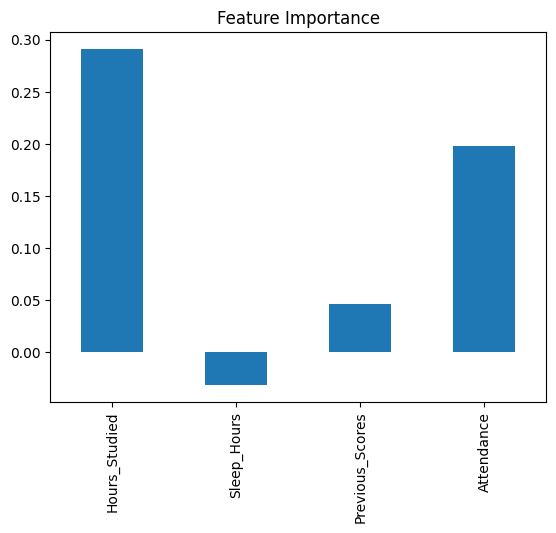

In [15]:
importance = pd.Series(lin_model.coef_, index=X.columns)
print(importance)
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()